In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### STEP 1 - Load Datasets

In [2]:
train = pd.read_csv(
    'store-sales-time-series-forecasting/train.csv',
    parse_dates=['date'],
    index_col='date'
)

holidays = pd.read_csv(
    'store-sales-time-series-forecasting/holidays_events.csv',
    parse_dates=['date'],
    index_col='date'
)

print(train.shape)
print(holidays.shape)

train.head()

(3000888, 5)
(350, 5)


,id,store_nbr,family,sales,onpromotion
date,,,,,
2013-01-01,0,1,AUTOMOTIVE,0.0,0
2013-01-01,1,1,BABY CARE,0.0,0
2013-01-01,2,1,BEAUTY,0.0,0
2013-01-01,3,1,BEVERAGES,0.0,0
2013-01-01,4,1,BOOKS,0.0,0


In [3]:
print(train.info())
print(train.describe())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3000888 entries, 2013-01-01 to 2017-08-15
Data columns (total 5 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   store_nbr    int64  
 2   family       object 
 3   sales        float64
 4   onpromotion  int64  
dtypes: float64(1), int64(3), object(1)
memory usage: 137.4+ MB
None
                 id     store_nbr         sales   onpromotion
count  3.000888e+06  3.000888e+06  3.000888e+06  3.000888e+06
mean   1.500444e+06  2.750000e+01  3.577757e+02  2.602770e+00
std    8.662819e+05  1.558579e+01  1.101998e+03  1.221888e+01
min    0.000000e+00  1.000000e+00  0.000000e+00  0.000000e+00
25%    7.502218e+05  1.400000e+01  0.000000e+00  0.000000e+00
50%    1.500444e+06  2.750000e+01  1.100000e+01  0.000000e+00
75%    2.250665e+06  4.100000e+01  1.958473e+02  0.000000e+00
max    3.000887e+06  5.400000e+01  1.247170e+05  7.410000e+02


In [4]:
print(train.index.min(), train.index.max())

2013-01-01 00:00:00 2017-08-15 00:00:00


### STEP 2 - Detect Patterns (Visual)

#### A. Total sales over time

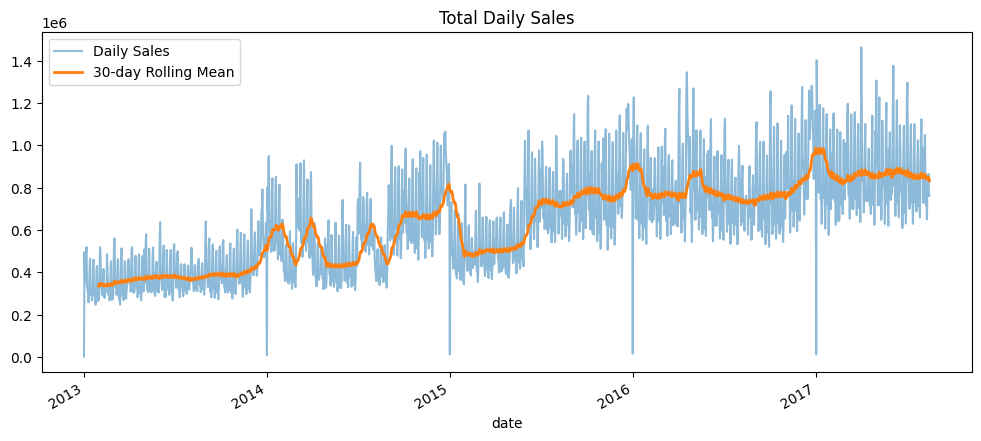

In [5]:
import matplotlib.pyplot as plt

# Aggregate all sales per day
daily = train.groupby("date")["sales"].sum()

plt.figure(figsize=(12,5))
plt.plot(daily, label="Daily Sales", alpha=0.5)

# Rolling mean (smooth)
daily.rolling(30).mean().plot(label="30-day Rolling Mean", linewidth=2)

plt.title("Total Daily Sales")
plt.legend()
plt.show()

##### Insight:
	•	Sales show a clear upward trend over time.
	•	The data is highly noisy on a daily level.
	•	The rolling mean reveals repeating seasonal peaks.
	•	There are sharp drops, likely due to holidays or closures.
	•	Variability increases with higher sales levels.

#### B. Weekly Seasonality

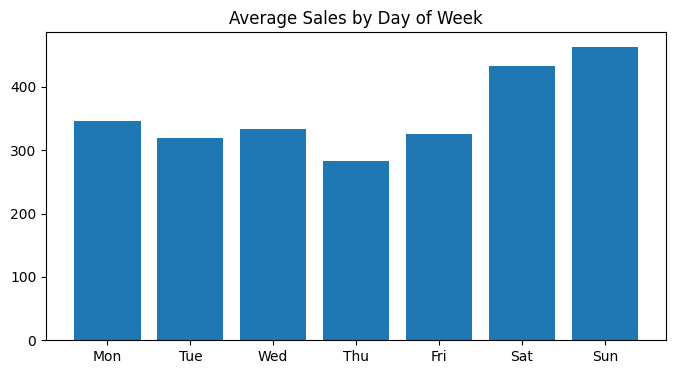

In [6]:
dow_sales = train.groupby(train.index.dayofweek)['sales'].mean()

plt.figure(figsize=(8, 4))
plt.bar(range(7), dow_sales)
plt.xticks(range(7), ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"])
plt.title("Average Sales by Day of Week")
plt.show()

##### INSIGHT:
* Sales are higher on weekends (Sat, Sun).
* Midweek (especially Thursday) shows lower demand.
* Clear weekly pattern exists.

Include:
* day_of_week
* Supports use of:
* lag7 (weekly dependency)

#### C. Montly Seasonality

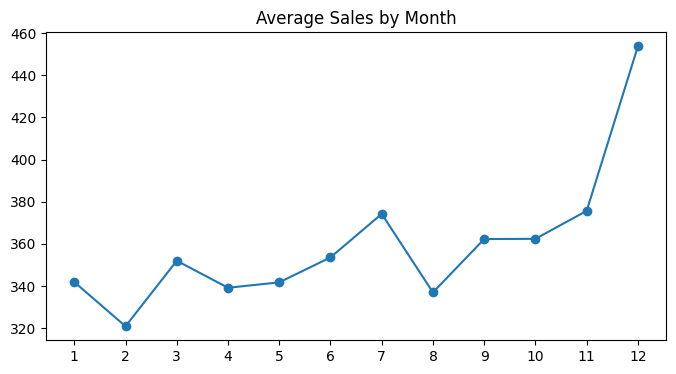

In [7]:
month_sales = train.groupby(train.index.month)["sales"].mean()

plt.figure(figsize=(8,4))
plt.plot(month_sales, marker='o')
plt.xticks(range(1,13))
plt.title("Average Sales by Month")
plt.show()

##### INSIGHT:
* Sales vary across months → clear yearly seasonality.
* Strong peak in December (likely holiday season).
* Some months show lower demand (e.g., February, August).

#### D. Promotion effect

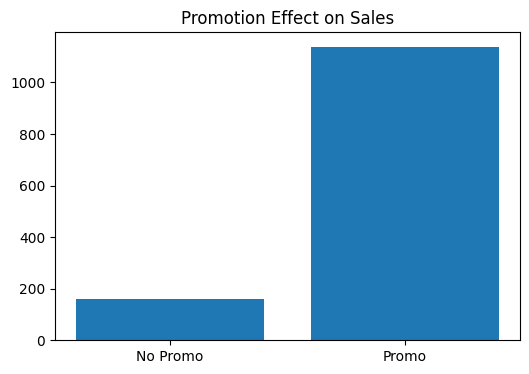

In [8]:
train['promo_flag'] = train['onpromotion'] > 0

promo_sales = train.groupby("promo_flag")["sales"].mean()

plt.figure(figsize=(6,4))
plt.bar(["No Promo", "Promo"], promo_sales)
plt.title("Promotion Effect on Sales")
plt.show()

##### INSIGHT:
* Sales are significantly higher during promotions.
* Promotion has a strong positive impact on demand.
* Include onpromotion as a key feature.

#### E. Holiday Visualization

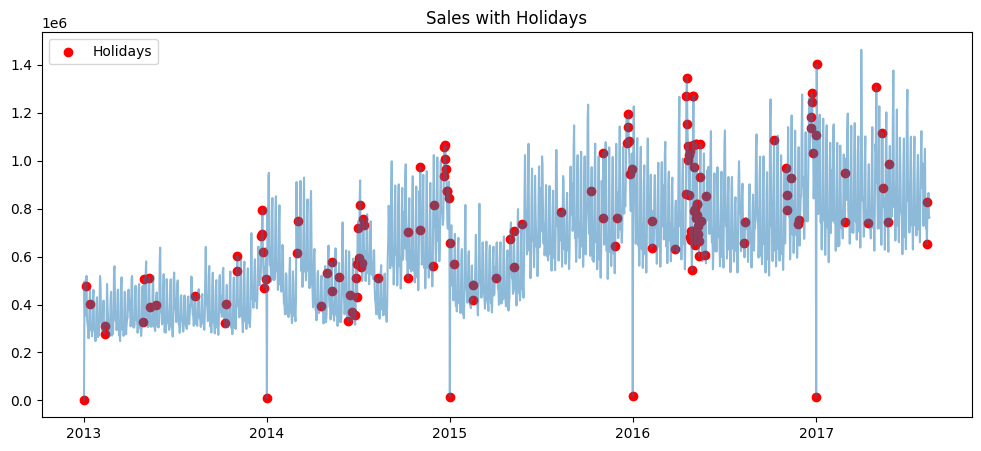

In [9]:
# only national holidays
holidays_nat = holidays[holidays["locale"] == "National"]

plt.figure(figsize=(12,5))
plt.plot(daily, alpha=0.5)

# mark holidays
plt.scatter(
    holidays_nat.index,
    daily.reindex(holidays_nat.index),
    color="red",
    label="Holidays"
)

plt.title("Sales with Holidays")
plt.legend()
plt.show()

##### INSIGHT
* Some holidays correspond to spikes in sales.
* Others align with sharp drops (near zero).
* Holiday impact is not uniform (depends on type).
* Add holiday indicator feature (is_holiday).
* Holidays are an important external signal.

Text(0.5, 1.0, 'Periodogram')

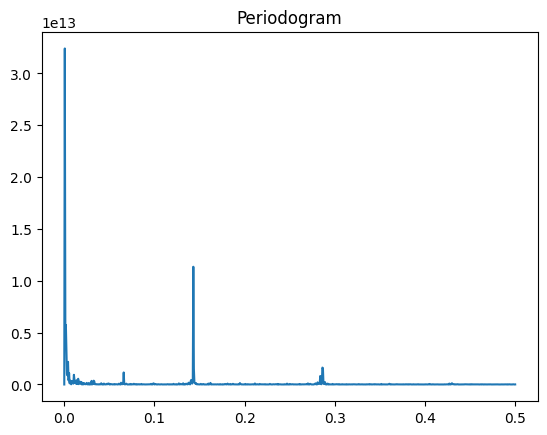

In [10]:
from scipy.signal import periodogram
# show what cycle exist in the data?

freqs, power = periodogram(daily)
plt.plot(freqs, power)
plt.title('Periodogram')

##### Insight:
* Big spike near zero -> strong trend increase (slow change over time) -> Trend
* spike around 0.14 -> convert to periode : p = 1/0.14 = 7 -> show weekly seasonality(strong)
* spike around 0.03 -> monthly pattern (weaker but exist)



#### Target Distribution

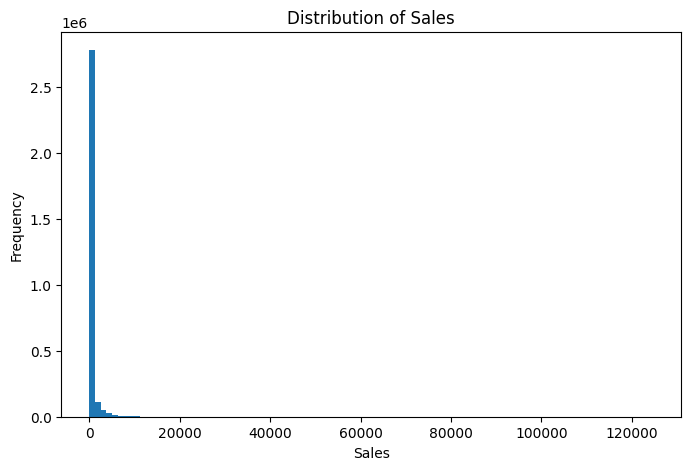

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(train["sales"], bins=100)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

##### INSIGHT:
* Sales distribution is highly right-skewed, with most values close to zero and a long tail of large values.
* This indicates the presence of extreme values and high variance.
* Therefore, a log transformation is applied to stabilize the distribution.

### STEP 3 - Feature Engineering

#### 3.1 Calender Feautures

In [12]:
df = train.copy()

# Time-based features
df["year"] = df.index.year
df["month"] = df.index.month
df["day"] = df.index.day
df["day_of_week"] = df.index.dayofweek
df["day_of_year"] = df.index.dayofyear

#### 3.2 Promotion Feature

In [13]:
# Already there, but ensure correct type
df["onpromotion"] = df["onpromotion"].fillna(0)

#### 3.3 Holiday Feature

In [14]:
# Only national holidays
holidays_nat = holidays[holidays["locale"] == "National"].copy()

# Create flag
holidays_nat["is_holiday"] = 1

# Merge with main df
df = df.merge(
    holidays_nat[["is_holiday"]],
    left_index=True,
    right_index=True,
    how="left"
)

df["is_holiday"] = df["is_holiday"].fillna(0)

#### 3.4 Encode Product Family

In [15]:
df["family"] = df["family"].astype("category")
df["family_enc"] = df["family"].cat.codes

#### 3.5 Lag Features

In [16]:
df = df.sort_values(["store_nbr", "family", "date"])

# Group per time series
group = df.groupby(["store_nbr", "family"])["sales"]

# 7 → weekly pattern
# 14, 21, 28 → extended cycles

df["lag7"]  = group.shift(7)
df["lag14"] = group.shift(14)
df["lag21"] = group.shift(21)
df["lag28"] = group.shift(28)

#### 3.6 Rolling Features (trend smoothing)

In [17]:
df["rmean7"]  = group.shift(7).rolling(7).mean()
df["rmean14"] = group.shift(7).rolling(14).mean()
df["rmean28"] = group.shift(7).rolling(28).mean()

In [18]:
## improvement option
group = df.groupby(["store_nbr", "family"])["sales"]

df["rstd7"]  = group.shift(7).rolling(7).std()
df["rstd14"] = group.shift(7).rolling(14).std()
df["rstd28"] = group.shift(7).rolling(28).std()

#### 3.7 Handle Missing Values

In [19]:
df = df.dropna()

#### 3.8 Target Transformation

In [20]:
df["sales_log"] = np.log1p(df["sales"])

/var/folders/3q/lzdtqc8n0hs2f7nfdlfb5fnw0000gn/T/ipykernel_94255/1610140852.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["sales_log"] = np.log1p(df["sales"])


### STEP 4 - Train Model

#### 4.1 Define Feature

In [21]:
FEATURES = [
    # identity
    "store_nbr",
    "family_enc",

    # external
    "onpromotion",
    "is_holiday",

    # time
    "year",
    "month",
    "day_of_week",
    "day_of_year",

    # lag
    "lag7", "lag14", "lag21", "lag28",

    # rolling
    "rmean7", "rmean14", "rmean28",
    "rstd7", "rstd14", "rstd28",
]

#### 5.1 Time-based split

In [22]:
# Sort by time
df = df.sort_index()

# Define horizon
HORIZON = 16

# Split
cutoff = df.index.max() - pd.Timedelta(days=HORIZON)

train_df = df[df.index <= cutoff]
val_df   = df[df.index > cutoff]

print("Train range:", train_df.index.min(), "→", train_df.index.max())
print("Val range:", val_df.index.min(), "→", val_df.index.max())

Train range: 2013-02-04 00:00:00 → 2017-07-30 00:00:00
Val range: 2017-07-31 00:00:00 → 2017-08-15 00:00:00


In [23]:
X_train = train_df[FEATURES]
y_train = train_df["sales_log"]

X_val = val_df[FEATURES]
y_val = val_df["sales"]

#### Train Model

In [24]:
from sklearn.ensemble import HistGradientBoostingRegressor

# model = HistGradientBoostingRegressor(
#     max_iter=300,
#     learning_rate=0.05,
#     max_leaf_nodes=31,
#     random_state=42
# )

model = HistGradientBoostingRegressor(
    max_iter=400,
    learning_rate=0.05,
    max_leaf_nodes=63,
    min_samples_leaf=20,
    l2_regularization=0.1,
    random_state=42
)

model.fit(X_train, y_train)

HistGradientBoostingRegressor(l2_regularization=0.1, learning_rate=0.05,
                              max_iter=400, max_leaf_nodes=63, random_state=42)

In [25]:
import numpy as np

y_pred_log = model.predict(X_val)
y_pred = np.expm1(y_pred_log)

In [26]:
# Predict on TRAIN
y_train_pred_log = model.predict(X_train)
y_train_pred = np.expm1(y_train_pred_log)
y_train_pred = np.clip(y_train_pred, 0, None)

# Predict on VALIDATION
y_val_pred_log = model.predict(X_val)
y_val_pred = np.expm1(y_val_pred_log)
y_val_pred = np.clip(y_val_pred, 0, None)

from sklearn.metrics import mean_squared_log_error
import numpy as np

rmsle_train = np.sqrt(mean_squared_log_error(train_df["sales"], y_train_pred))
rmsle_val   = np.sqrt(mean_squared_log_error(val_df["sales"], y_val_pred))

print("Train RMSLE:", rmsle_train)
print("Val   RMSLE:", rmsle_val)

Train RMSLE: 0.4122640110299102
Val   RMSLE: 0.40984097437455486


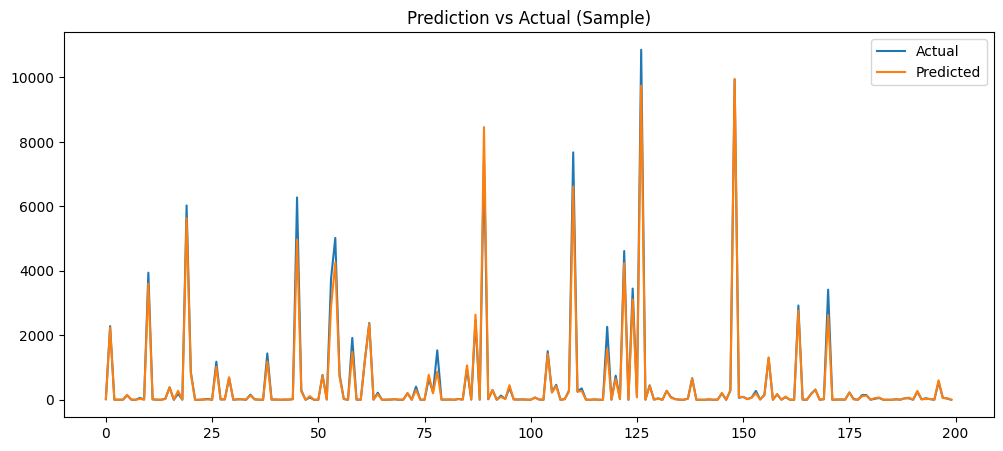

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_val.values[:200], label="Actual")
plt.plot(y_pred[:200], label="Predicted")
plt.legend()
plt.title("Prediction vs Actual (Sample)")
plt.show()

In [28]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_val,
    y_val,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

importance = pd.Series(result.importances_mean, index=FEATURES)
importance.sort_values(ascending=False).head(10)

lag7           0.000772
rmean7         0.000383
rmean28        0.000209
rmean14        0.000146
lag28          0.000096
lag14          0.000088
onpromotion    0.000064
family_enc     0.000063
rstd28         0.000041
lag21          0.000037
dtype: float64

#####  Feature Importance Insights
* Lag features (especially lag7) are the most important predictors, indicating strong weekly dependency in sales.
* Rolling mean features also contribute significantly, capturing short-term trends.
* Promotion has a positive but smaller impact compared to historical patterns.
* Calendar features are less important, as lag features already encode seasonality.